# Dust Attenuation and Emission

diffsed implements a generalized two-component dust model (Charlot & Fall
2000) with pluggable attenuation curves. This notebook visualizes all
seven available curves, explores the two-component model, and shows the
panchromatic SED from UV through IR.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from diffsed import (
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
    two_component_dust,
)
from diffsed.models.dust.attenuation import DUST_LAWS, get_dust_law

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, setup_style

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

## 1. All Seven Attenuation Curves

Each curve $k(\lambda)$ describes the wavelength dependence of dust
attenuation, normalized at 5500 A. The two-component model then applies
the curve with separate optical depths for birth clouds and diffuse ISM.

In [2]:
wavelength = jnp.linspace(1000.0, 30000.0, 2000)

# Define curves and their extra kwargs
CURVES = [
    ("power_law", {}, "Power law (CF00)"),
    ("calzetti", {}, "Calzetti+2000"),
    ("kriek_conroy", {"dust_bump_strength": 1.0, "dust_delta": 0.0}, "Kriek & Conroy 2013"),
    ("smc", {}, "SMC (Gordon+2003)"),
    ("cardelli", {"dust_Rv": 3.1}, "Cardelli+1989 (MW)"),
    ("salim", {}, "Salim+2018"),
    ("li08", {}, "Li+2008"),
]

curve_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

W0321 03:48:14.997636 14135355 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


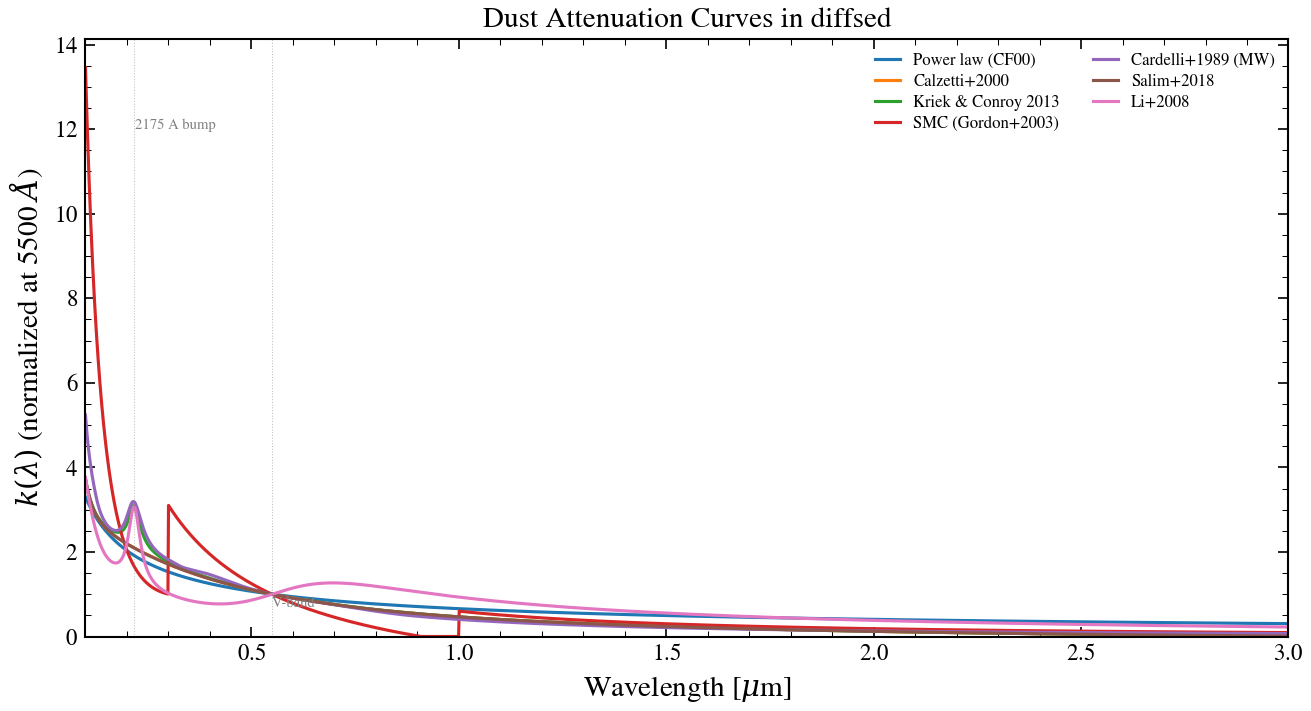

In [3]:
# --- FIGURE 1: All attenuation curves ---
fig, ax = plt.subplots(figsize=(9, 5))
for (name, kwargs, label), color in zip(CURVES, curve_colors):
    dust_fn = get_dust_law(name)
    k = dust_fn(wavelength, **kwargs)
    ax.plot(np.array(wavelength) / 1e4, np.array(k), label=label, color=color, lw=1.5)

ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(r"$k(\lambda)$ (normalized at 5500 $\AA$)")
ax.set_title("Dust Attenuation Curves in diffsed")
ax.axvline(0.55, ls=":", color="grey", lw=0.5, alpha=0.5)
ax.annotate(
    "V-band", xy=(0.55, 0.05), xycoords=("data", "axes fraction"), fontsize=7, color="grey"
)
ax.axvline(0.2175, ls=":", color="grey", lw=0.5, alpha=0.5)
ax.annotate(
    "2175 A bump", xy=(0.22, 0.85), xycoords=("data", "axes fraction"), fontsize=7, color="grey"
)
ax.set_xlim(0.1, 3.0)
ax.set_ylim(0, None)
ax.legend(fontsize=8, frameon=False, ncol=2)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "03_attenuation_curves.pdf"), bbox_inches="tight")
plt.show()

## 2. Two-Component Model Exploration

The Charlot & Fall model has two components:
- **Birth cloud** ($\tau_{\rm bc}$): extra attenuation on young stars
  (age < $t_{\rm birth} \approx 10$ Myr)
- **Diffuse ISM** ($\tau_{\rm diff}$): attenuation on all stars

We show how varying each component changes the transmission.

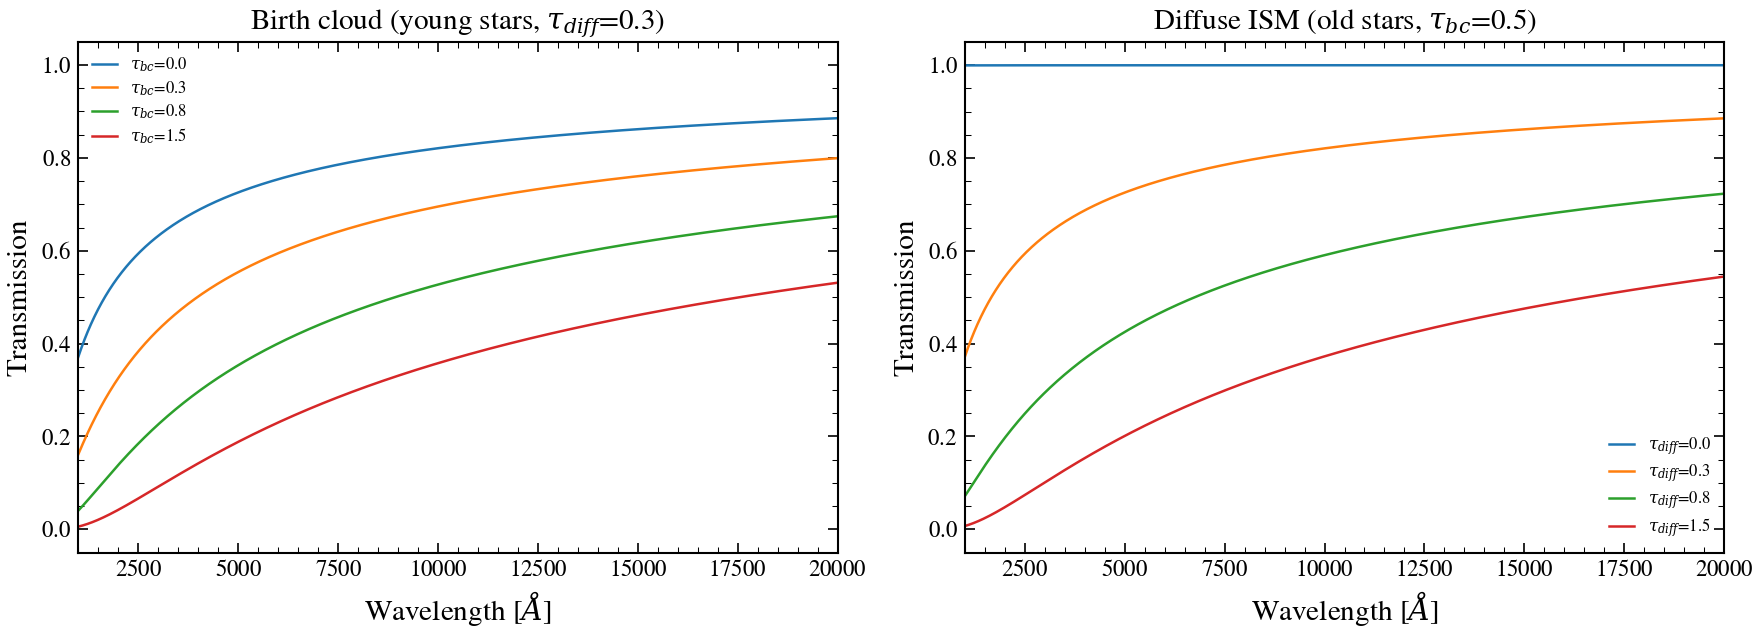

In [4]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
ssp_ages_yr = 10.0 ** (ssp_data.ssp_lg_age_gyr + 9.0)

# --- FIGURE 2: Two-component dust transmission for different tau values ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Vary tau_bc with fixed tau_diff
ax = axes[0]
tau_diff_fixed = 0.3
for tau_bc, color in zip([0.0, 0.3, 0.8, 1.5], curve_colors[:4]):
    transmission = two_component_dust(
        ssp_data.ssp_wave,
        ssp_ages_yr,
        tau_v1=tau_bc,
        tau_v2=tau_diff_fixed,
        law_bc="power_law",
        law_diff="power_law",
        n_slope=-0.7,
    )
    # Show for a young population (index ~20, ~10 Myr)
    young_idx = 20
    ax.plot(
        np.array(ssp_data.ssp_wave),
        np.array(transmission[young_idx]),
        label=f"$\\tau_{{bc}}$={tau_bc}",
        color=color,
        lw=1.2,
    )
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel("Transmission")
ax.set_title(f"Birth cloud (young stars, $\\tau_{{diff}}$={tau_diff_fixed})")
ax.set_xlim(1000, 20000)
ax.legend(fontsize=8, frameon=False)

# Panel B: Vary tau_diff with fixed tau_bc
ax = axes[1]
tau_bc_fixed = 0.5
for tau_diff, color in zip([0.0, 0.3, 0.8, 1.5], curve_colors[:4]):
    transmission = two_component_dust(
        ssp_data.ssp_wave,
        ssp_ages_yr,
        tau_v1=tau_bc_fixed,
        tau_v2=tau_diff,
        law_bc="power_law",
        law_diff="power_law",
        n_slope=-0.7,
    )
    # Show for an old population (index ~80, ~1 Gyr)
    old_idx = 80
    ax.plot(
        np.array(ssp_data.ssp_wave),
        np.array(transmission[old_idx]),
        label=f"$\\tau_{{diff}}$={tau_diff}",
        color=color,
        lw=1.2,
    )
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel("Transmission")
ax.set_title(f"Diffuse ISM (old stars, $\\tau_{{bc}}$={tau_bc_fixed})")
ax.set_xlim(1000, 20000)
ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "03_two_component.pdf"), bbox_inches="tight")
plt.show()

## 3. Effect of Attenuation Curve Choice on SED

We generate an intrinsic SED and show how different dust laws modify
the spectrum.

In [5]:
# Create a model and generate intrinsic + attenuated SEDs
spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Fixed(1.0),
    sfh_tsnorm_peak_lbt_gyr=Fixed(3.0),
    sfh_tsnorm_width_gyr=Fixed(2.0),
    sfh_tsnorm_skew=Fixed(0.0),
    sfh_tsnorm_trunc=Fixed(5.0),
    met_logzsol=Fixed(-0.2),
    dust_tau_bc=Fixed(0.0),
    dust_tau_diff=Fixed(0.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.0),
)
model_nodust = Model(spec, ssp_data)
params_nodust = {
    "sfh_tsnorm_log_peak_sfr": 1.0,
    "sfh_tsnorm_peak_lbt_gyr": 3.0,
    "sfh_tsnorm_width_gyr": 2.0,
    "sfh_tsnorm_skew": 0.0,
    "sfh_tsnorm_trunc": 5.0,
    "met_logzsol": -0.2,
    "dust_tau_bc": 0.0,
    "dust_tau_diff": 0.0,
    "dust_slope": -0.7,
    "redshift": 0.0,
}
sed_intrinsic = model_nodust.predict_sed(params_nodust)
wave_rest = ssp_data.ssp_wave

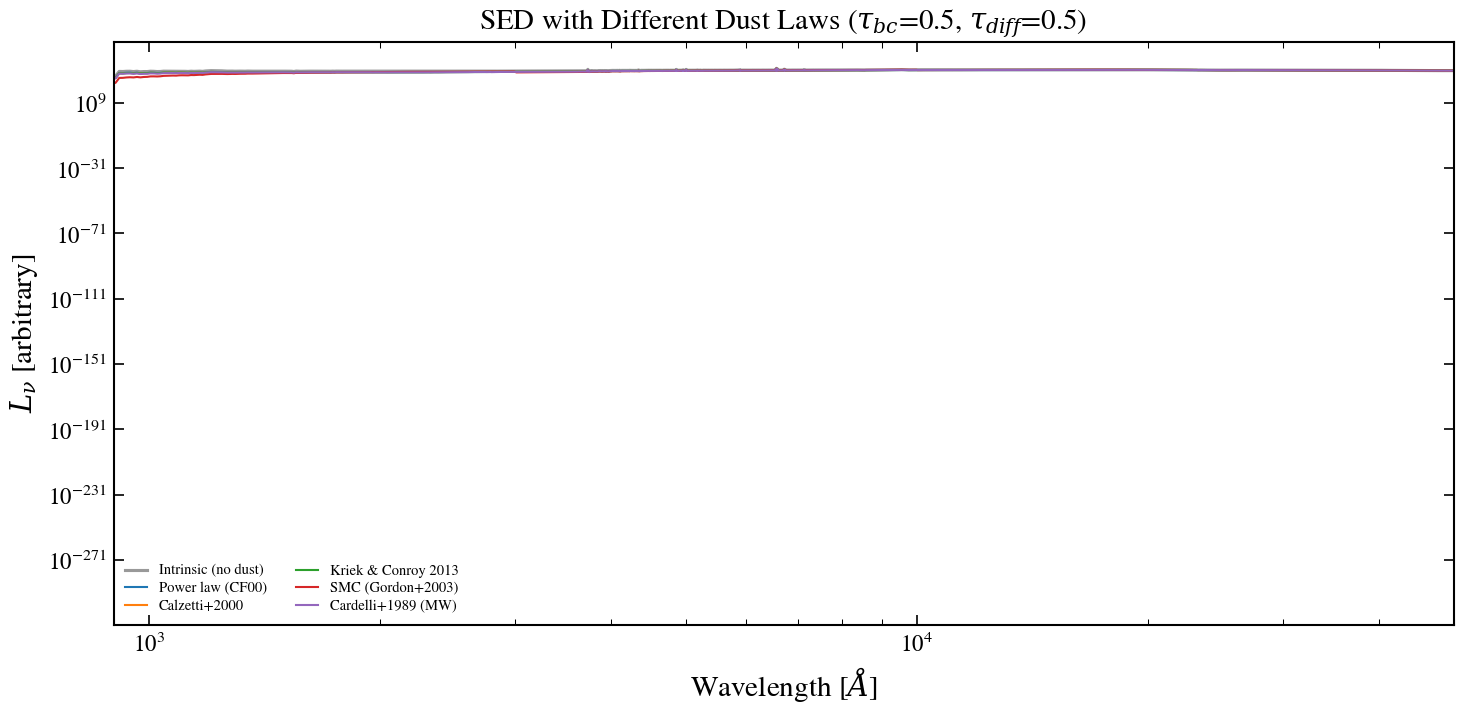

In [6]:
# --- FIGURE 3: Panchromatic SED with different dust laws ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    np.array(wave_rest),
    np.array(sed_intrinsic),
    "k-",
    lw=1.5,
    alpha=0.4,
    label="Intrinsic (no dust)",
)

tau_bc, tau_diff = 0.5, 0.5
for (name, kwargs, label), color in zip(CURVES[:5], curve_colors[:5]):
    transmission = two_component_dust(
        wave_rest,
        ssp_ages_yr,
        tau_v1=tau_bc,
        tau_v2=tau_diff,
        law_bc=name,
        law_diff=name,
        **kwargs,
    )
    # Apply dust to SSP-weighted SED (approximate: use average transmission)
    mean_trans = jnp.mean(transmission, axis=0)
    sed_dusty = sed_intrinsic * mean_trans
    ax.plot(np.array(wave_rest), np.array(sed_dusty), color=color, lw=1.0, label=label)

ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [arbitrary]")
ax.set_title(
    f"SED with Different Dust Laws ($\\tau_{{bc}}$={tau_bc}, $\\tau_{{diff}}$={tau_diff})"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(900, 50000)
ax.legend(fontsize=7, frameon=False, ncol=2)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "03_panchromatic_sed.pdf"), bbox_inches="tight")
plt.show()

## 4. UV Bump at 2175 A

The 2175 A feature is a defining characteristic of the Milky Way
extinction curve. Different dust laws handle it differently.

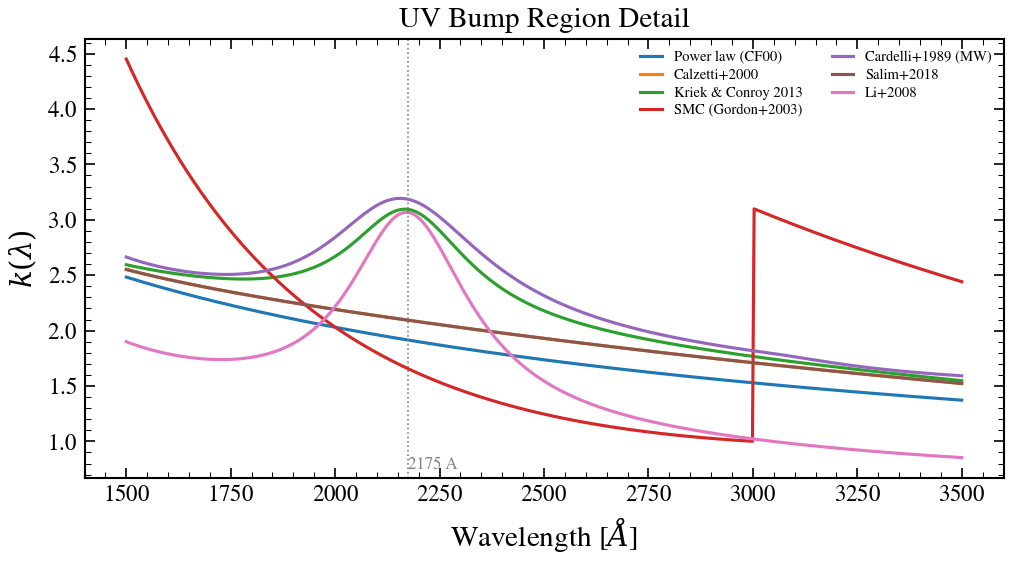

In [7]:
# --- FIGURE 4: UV bump zoom ---
fig, ax = plt.subplots(figsize=(7, 4))
wave_uv = jnp.linspace(1500.0, 3500.0, 500)

for (name, kwargs, label), color in zip(CURVES, curve_colors):
    dust_fn = get_dust_law(name)
    k = dust_fn(wave_uv, **kwargs)
    ax.plot(np.array(wave_uv), np.array(k), color=color, lw=1.5, label=label)

ax.axvline(2175, ls=":", color="grey", lw=0.8)
ax.annotate(
    "2175 A", xy=(2175, 0.02), xycoords=("data", "axes fraction"), fontsize=8, color="grey"
)
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$k(\lambda)$")
ax.set_title("UV Bump Region Detail")
ax.legend(fontsize=7, frameon=False, ncol=2)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "03_uv_bump.pdf"), bbox_inches="tight")
plt.show()

## 5. Dust Parameter Degeneracies

The age-dust degeneracy is one of the most important systematics in SED
fitting. Higher dust and older stellar populations both make galaxies
redder. We show the degeneracy direction in tau_diff vs age space.

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_73922/3116506344.py:24: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_grid = Model(spec_grid, ssp_data, filters=filters_ri)


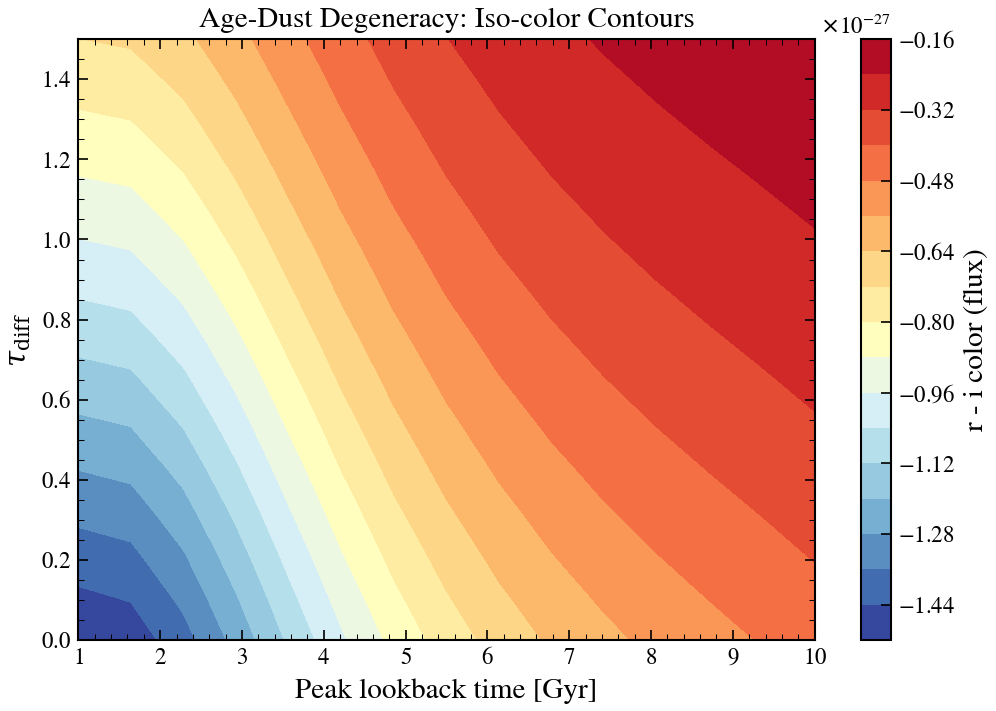

In [8]:
# --- FIGURE 5: tau_diff vs age color (simple illustration) ---
fig, ax = plt.subplots(figsize=(7, 5))

# Compute r-band - i-band color for a grid of (tau_diff, age)
filters_ri = load_filter_set(["sdss_r", "sdss_i"])
tau_range = np.linspace(0.0, 1.5, 15)
age_range = np.linspace(1.0, 10.0, 15)
color_grid = np.zeros((len(tau_range), len(age_range)))

for i_t, tau in enumerate(tau_range):
    for i_a, age in enumerate(age_range):
        spec_grid = ParamSpec(
            sfh_tsnorm_log_peak_sfr=Fixed(1.0),
            sfh_tsnorm_peak_lbt_gyr=Fixed(float(age)),
            sfh_tsnorm_width_gyr=Fixed(2.0),
            sfh_tsnorm_skew=Fixed(0.0),
            sfh_tsnorm_trunc=Fixed(5.0),
            met_logzsol=Fixed(-0.2),
            dust_tau_bc=Fixed(0.0),
            dust_tau_diff=Fixed(float(tau)),
            dust_slope=Fixed(-0.7),
            redshift=Fixed(0.1),
        )
        model_grid = Model(spec_grid, ssp_data, filters=filters_ri)
        params_grid = {
            "sfh_tsnorm_log_peak_sfr": 1.0,
            "sfh_tsnorm_peak_lbt_gyr": float(age),
            "sfh_tsnorm_width_gyr": 2.0,
            "sfh_tsnorm_skew": 0.0,
            "sfh_tsnorm_trunc": 5.0,
            "met_logzsol": -0.2,
            "dust_tau_bc": 0.0,
            "dust_tau_diff": float(tau),
            "dust_slope": -0.7,
            "redshift": 0.1,
        }
        phot = model_grid.predict_photometry(params_grid)
        if phot is not None and len(phot) == 2:
            color_grid[i_t, i_a] = float(phot[0] - phot[1])  # r - i color

im = ax.contourf(age_range, tau_range, color_grid, levels=20, cmap="RdYlBu_r")
plt.colorbar(im, ax=ax, label="r - i color (flux)")
ax.set_xlabel("Peak lookback time [Gyr]")
ax.set_ylabel(r"$\tau_{\rm diff}$")
ax.set_title("Age-Dust Degeneracy: Iso-color Contours")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "03_age_dust_degeneracy.pdf"), bbox_inches="tight")
plt.show()

## Summary

| Dust law | UV bump | Slope freedom | Best for |
|----------|---------|---------------|----------|
| Power law | No | Fixed | Fast, simple |
| Calzetti | No | Fixed | Starbursts |
| Kriek & Conroy | Yes (tunable) | Yes ($\delta$) | Prospector default |
| SMC | No | Fixed (steep) | High-z |
| Cardelli | Yes (MW) | $R_V$ free | MW sightlines |
| Salim | No | Modified Calzetti | DSPS default |
| Li+2008 | Yes (tunable) | 3 slopes | Maximum flexibility |

The two-component model separates birth-cloud and diffuse-ISM attenuation,
which is crucial for correctly interpreting UV-bright young stars versus
older populations.